<a href="https://colab.research.google.com/github/stnly999/Sleep-Efficiency-ML-A2/blob/main/14639482_Sleep_Efficiency_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload CSV to notebook
df = pd.read_csv('/content/drive/MyDrive/Machine_Learning-31005/Sleep_Efficiency_Updated.csv')
print(df.head())
print(df.info())
print(df.shape)

   ID  Age  Gender           Bedtime       Wakeup time  Sleep duration  \
0   1   65  Female  06/03/2021 01:00  06/03/2021 07:00             6.0   
1   2   69    Male  05/12/2021 02:00  05/12/2021 09:00             7.0   
2   3   40  Female  25/05/2021 21:30  25/05/2021 05:30             8.0   
3   4   40  Female  03/11/2021 02:30  03/11/2021 08:30             6.0   
4   5   57    Male  13/03/2021 01:00  13/03/2021 09:00             8.0   

   Sleep efficiency  REM sleep percentage  Deep sleep percentage  \
0              0.88                    18                     70   
1              0.66                    19                     28   
2              0.89                    20                     70   
3              0.51                    23                     25   
4              0.76                    27                     55   

   Light sleep percentage  Awakenings  Caffeine consumption  \
0                      12         0.0                   0.0   
1                   

In [ ]:
df.head(10)

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,06/03/2021 01:00,06/03/2021 07:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,05/12/2021 02:00,05/12/2021 09:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,25/05/2021 21:30,25/05/2021 05:30,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,03/11/2021 02:30,03/11/2021 08:30,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,13/03/2021 01:00,13/03/2021 09:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
5,6,36,Female,01/07/2021 21:00,01/07/2021 04:30,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
6,7,27,Female,21/07/2021 21:00,21/07/2021 03:00,6.0,0.54,28,25,47,2.0,50.0,0.0,Yes,1.0
7,8,53,Male,16/08/2021 00:30,16/08/2021 10:30,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
8,9,41,Female,05/04/2021 02:30,05/04/2021 08:30,6.0,0.79,28,55,17,3.0,50.0,0.0,No,1.0
9,10,11,Female,16/09/2021 01:00,16/09/2021 10:00,9.0,0.55,18,37,45,4.0,0.0,0.0,No,0.0


In [ ]:
# Basic stats
print(df.describe())

               ID         Age  Sleep duration  Sleep efficiency  \
count  618.000000  618.000000      618.000000        618.000000   
mean   309.500000   40.344660        7.448220          0.790259   
std    178.545512   13.082805        0.843838          0.133475   
min      1.000000    9.000000        5.000000          0.500000   
25%    155.250000   29.000000        7.000000          0.702500   
50%    309.500000   40.000000        7.500000          0.820000   
75%    463.750000   52.000000        8.000000          0.900000   
max    618.000000   69.000000       10.000000          0.990000   

       REM sleep percentage  Deep sleep percentage  Light sleep percentage  \
count            618.000000             618.000000              618.000000   
mean              22.569579              53.163430               24.266990   
std                3.547206              15.497712               15.106266   
min               15.000000              18.000000                7.000000   
25%   

In [ ]:
# Look for any missing values
print(df.isnull().sum())

ID                         0
Age                        0
Gender                     0
Bedtime                    0
Wakeup time                0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                27
Caffeine consumption      36
Alcohol consumption       21
Smoking status             0
Exercise frequency         7
dtype: int64


In [ ]:
df['stage_sum'] = df['REM sleep percentage'] + df['Deep sleep percentage'] + df['Light sleep percentage']
print(df['stage_sum'].describe())

count    618.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: stage_sum, dtype: float64


## Data Dictionary & Feature Interpretation

### Target Variable
- **Sleep efficiency:** Proportion (0–1 scale), mean = 0.79
  - 0.50 = pretty rough night (only half of time in bed was actually spent asleep)
  - 0.99 = basically perfect
  - Distribution looks roughly normal but a bit left-skewed (more on this below)

### Physiological/Sleep Architecture Features
**Note:** Not using these as model inputs (see Research Question below), but they're only knowable after someone's already slept, which breaks
the whole point of the project. Keeping them here just for EDA/completeness.

- **REM sleep %:** Mean 22.6%, range 15–30%
- **Deep sleep %:** Mean 53.2%, range 18–75%
- **Light sleep %:** Mean 24.3%, range 7–63%
- **Sum check:** REM + Deep + Light = ~100% (valid, no data weirdness here)

### Behavioral Features
- **Caffeine consumption:** mg/day
  - Range 0–200mg, mean 24.5mg
  - Probably self-reported from a food/drink diary
  - Missing: 36 values (5.8%)
  
- **Alcohol consumption:** Discrete scale (0–5 drinks/week)
  - All whole numbers
  - Mean 1.11 drinks/week
  - Missing: 21 values (3.4%)
  
- **Exercise frequency:** Times per week
  - Range 0–5x/week, mean 1.79x/week
  - Missing: 7 values (1.1%)

### Demographic Features
- **Age:** Range 9–69, mean 40.3 years
- **Gender:** Male/Female

### Temporal Features
- **Bedtime & Wakeup time:** Came in as full datetime strings, needed
  parsing (turned out to be day/month/year format, not the month/day/year
  I assumed at first which caused an error, fixed below)
  - Extracting hour of day; the actual date doesn't matter, just what
    time someone went to bed/woke up
  
- **Sleep duration:** Already calculated for us (hours)
  - Range 5–10 hours, mean 7.45 hours

### Data Quality Notes
- 1 row missing overall (619 → 618 after the "updated" dataset version)
- Awakenings: 27 missing (4.4%)
- Caffeine: 36 missing (5.8%)
- Alcohol: 21 missing (3.4%)
- Exercise: 7 missing (1.1%)
- Handling this properly further down, decided on median imputation
  after checking whether the missingness looked random

## Research Question

### Problem Statement
Predict sleep efficiency (0–1) directly from lifestyle, behavioral,
and demographic inputs a person knows before they sleep, therefore
predictions are usable for "what if I changed X" experimentation
(e.g., "if I move my bedtime earlier or cut caffeine, how much
might my efficiency improve?").

### Deployment Constraint (this one took me a while to catch)
At prediction time, a user has NOT yet slept. They only know:
- Their demographics (age, gender)
- Planned bedtime/wake time
- Today's behavior (caffeine, alcohol, smoking, exercise)

They do NOT know (yet): REM%, Deep%, Light%, Awakenings, therefore these
are measured DURING/AFTER sleep and cannot be used as model inputs
without breaking the use case. If I trained on those, the model
would look great on paper but be useless for the actual use case,
since nobody has that info in advance.

### Input (what the model actually gets)
Age, Gender, Bedtime, Wakeup time, Sleep duration, Caffeine
consumption, Alcohol consumption, Smoking status, Exercise frequency

### Excluded (data leakage risk)
REM sleep %, Deep sleep %, Light sleep %, Awakenings can only be
known after sleep happens

### Output
Predicted Sleep efficiency (continuous, 0–1)

### Evaluation Metric
MAE (Mean Absolute Error) I picked this because it's easy to explain:
an MAE of 0.05 just means "predictions are off by about 5 percentage
points on average," which is a lot more intuitive than something
like RMSE for someone actually trying to use this.

### Why This Matters
Sleep efficiency is basically a proxy for sleep quality, but just
looking at duration doesn't tell the whole story. There's a 2021
study on 82 university athletes that found sleep quality had a
*stronger* link to reduced injury/illness risk (Odds Ratio 0.6) than
sleep duration alone (Odds Ratio 0.8) (Hamlin et al., 2021). That
suggests quality-based metrics like efficiency might carry more
useful signal than just tracking hours slept.

One caveat worth flagging: that study used self-rated sleep quality
(a 1–5 scale), not sleep efficiency % specifically, related, but
not literally the same measurement. Treating this as supporting
evidence for why quality matters generally, not as direct proof the
efficiency metric itself is validated.

**Source:** Hamlin, M.J., et al. (2021). The Effect of Sleep Quality
and Quantity on Athlete's Health and Perceived Training Quality.
*Frontiers in Sports and Active Living*, 3:705650.

## Initial Exploratory Data Analysis


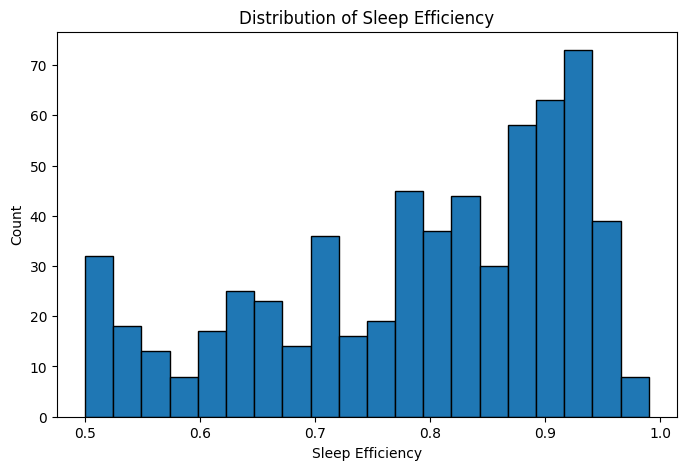

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Sleep efficiency'], bins=20, edgecolor='black')
plt.xlabel('Sleep Efficiency')
plt.ylabel('Count')
plt.title('Distribution of Sleep Efficiency')
plt.show()

In [ ]:
# low-efficiency cluster
low_eff = df[df['Sleep efficiency'] <= 0.55]
print(low_eff.shape)
print(low_eff[['Age', 'Alcohol consumption', 'Caffeine consumption',
               'Smoking status', 'Exercise frequency']].describe())

(58, 16)
             Age  Alcohol consumption  Caffeine consumption  \
count  58.000000            55.000000             55.000000   
mean   34.948276             2.454545             21.363636   
std    13.403878             1.751382             24.729173   
min     9.000000             0.000000              0.000000   
25%    27.000000             1.000000              0.000000   
50%    34.000000             2.000000              0.000000   
75%    40.000000             4.000000             50.000000   
max    65.000000             5.000000             75.000000   

       Exercise frequency  
count           57.000000  
mean             1.368421  
std              1.383985  
min              0.000000  
25%              0.000000  
50%              1.000000  
75%              3.000000  
max              5.000000  


In [ ]:
# The complement: everyone NOT in the low-efficiency cluster
rest = df[df['Sleep efficiency'] > 0.55]

print("Low-efficiency cluster (n=58):")
print(low_eff[['Age', 'Alcohol consumption', 'Caffeine consumption',
               'Exercise frequency']].mean())

print("\nRest of dataset (n=560):")
print(rest[['Age', 'Alcohol consumption', 'Caffeine consumption',
            'Exercise frequency']].mean())

Low-efficiency cluster (n=58):
Age                     34.948276
Alcohol consumption      2.454545
Caffeine consumption    21.363636
Exercise frequency       1.368421
dtype: float64

Rest of dataset (n=560):
Age                     40.903571
Alcohol consumption      0.981550
Caffeine consumption    24.857685
Exercise frequency       1.823105
dtype: float64


In [ ]:
from scipy import stats

for col in ['Age', 'Alcohol consumption', 'Caffeine consumption', 'Exercise frequency']:
    low_vals = low_eff[col].dropna()
    rest_vals = rest[col].dropna()
    t_stat, p_val = stats.ttest_ind(low_vals, rest_vals)
    print(f"{col}: low-eff mean={low_vals.mean():.2f}, rest mean={rest_vals.mean():.2f}, p={p_val:.4f}")

Age: low-eff mean=34.95, rest mean=40.90, p=0.0009
Alcohol consumption: low-eff mean=2.45, rest mean=0.98, p=0.0000
Caffeine consumption: low-eff mean=21.36, rest mean=24.86, p=0.4464
Exercise frequency: low-eff mean=1.37, rest mean=1.82, p=0.0203


### Target Distribution

Looking at the histogram of Sleep Efficiency, it's left-skewed overall
where most of the mass sits high (0.85–0.95), tapering off toward lower
values. But there's something more interesting than just "skewed":
the very first bin (0.50–0.52) actually has more people in it (32)
than several bins right after it. That's not a smooth taper, that's
a spike right at the floor value.

Checked this properly by pulling out everyone with efficiency ≤ 0.55
(n=58) and comparing them against everyone else, using t-tests:

| Feature | Low-eff mean | Rest mean | p-value | Significant? |
|---|---|---|---|---|
| Age | 34.95 | 40.90 | 0.0009 | Yes |
| Alcohol consumption | 2.45 | 0.98 | <0.0001 | Yes (by far the strongest) |
| Exercise frequency | 1.37 | 1.82 | 0.0203 | Yes, but weaker |
| Caffeine consumption | 21.36 | 24.86 | 0.4464 | No |

Alcohol is clearly the standout here, the low-efficiency group drinks
roughly 2.5x more on average, and that's not something you'd see by
chance (p<0.0001). Age and exercise show real differences too, though
weaker. Caffeine turned out to not matter at all in this dataset,
which honestly surprised me a bit going in.

Worth being careful here, these are just correlational group
comparisons on observational data. Can't say alcohol *causes* worse
efficiency, just that it's associated with it. Still, it's a strong
enough signal that I expect alcohol to matter a lot once we get to
actual modeling.

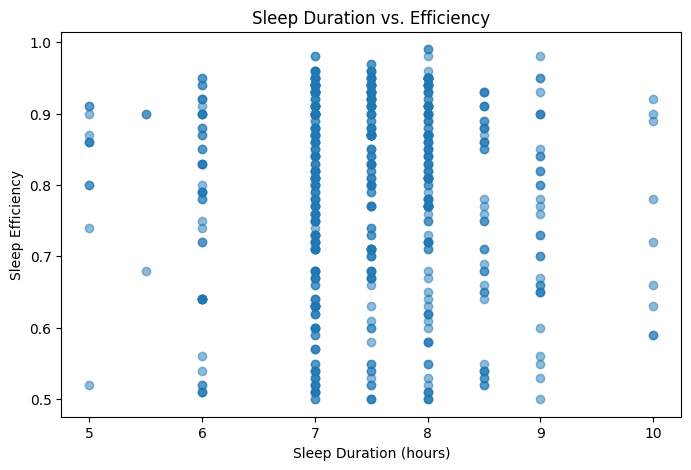

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sleep duration'], df['Sleep efficiency'], alpha=0.5)
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Sleep Efficiency')
plt.title('Sleep Duration vs. Efficiency')
plt.show()

In [ ]:
correlation = df['Sleep duration'].corr(df['Sleep efficiency'])
print(f"Correlation: {correlation:.3f}")

Correlation: -0.025


In [ ]:
# Group by rounded duration, see mean efficiency per group
df.groupby(df['Sleep duration'].round())['Sleep efficiency'].mean()

,Sleep efficiency
Sleep duration,
5.0,0.820909
6.0,0.773000
7.0,0.781509
8.0,0.803322
9.0,0.754062
10.0,0.742222


### Sleep Duration vs. Efficiency

My first look at the scatter plot made me think there was some kind
of "diminishing returns" thing going on, things like efficiency capping out
around 7-8 hours. But after checking the actual correlation number
(r = -0.025) showed that's basically nothing. Essentially no linear
relationship at all.

Grouped the data by rounded duration to double check:

| Duration (hrs) | Mean Efficiency |
|---|---|
| 5 | 0.821 |
| 6 | 0.773 |
| 7 | 0.782 |
| 8 | 0.803 |
| 9 | 0.754 |
| 10 | 0.742 |

Mean efficiency stays in a pretty narrow band (0.74–0.82) no matter
the duration, there is no clear trend up or down. If anything the longer
durations (9-10h) look slightly *lower*, but the gap is small and
there probably aren't many people sleeping 10 hours anyway, so I
wouldn't read too much into that.

**Bottom line:** sleep duration alone doesn't really predict
efficiency in this dataset. That was a bit of a surprise, but it
makes the case for leaning on behavioral features like alcohol
instead of assuming "more sleep = better sleep."

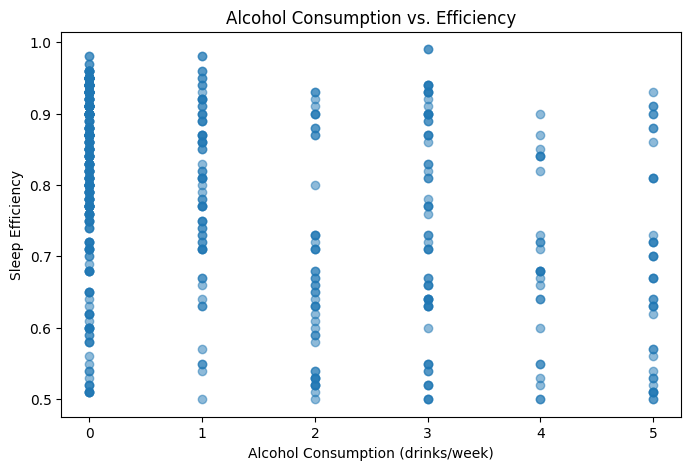

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Alcohol consumption'], df['Sleep efficiency'], alpha=0.5)
plt.xlabel('Alcohol Consumption (drinks/week)')
plt.ylabel('Sleep Efficiency')
plt.title('Alcohol Consumption vs. Efficiency')
plt.show()

In [ ]:
df.groupby('Alcohol consumption')['Sleep efficiency'].mean()

,Sleep efficiency
Alcohol consumption,
0.0,0.831268
1.0,0.801429
2.0,0.682857
3.0,0.749692
4.0,0.689231
5.0,0.681250


In [ ]:
correlation = df['Alcohol consumption'].corr(df['Sleep efficiency'])
print(f"Correlation: {correlation:.3f}")

Correlation: -0.394


### Alcohol Consumption vs. Efficiency

Unlike duration, alcohol actually shows something real:
correlation r = -0.394 (moderate negative).

| Alcohol (drinks/week) | Mean Efficiency |
|---|---|
| 0 | 0.831 |
| 1 | 0.801 |
| 2 | 0.683 |
| 3 | 0.750 |
| 4 | 0.689 |
| 5 | 0.681 |

There's a clear downward trend overall, starting from ~0.83 at zero drinks
down to ~0.68 at 4-5 drinks, about a 0.15 drop, which is a lot on a
0-1 scale. It's not a perfectly smooth line (there's a small bump
back up at 3 drinks), which is probably just smaller sample sizes at
the higher end, but the overall pattern lines up with what the
t-test found earlier. Alcohol is clearly the strongest behavioral
signal so far, way more than duration or caffeine.

In [ ]:
df['Bedtime'] = pd.to_datetime(df['Bedtime'], format='%d/%m/%Y %H:%M')
df['Wakeup time'] = pd.to_datetime(df['Wakeup time'], format='%d/%m/%Y %H:%M')

df['Bedtime_hour'] = df['Bedtime'].dt.hour
df['Wakeup_hour'] = df['Wakeup time'].dt.hour

print(df[['Bedtime', 'Bedtime_hour', 'Wakeup time', 'Wakeup_hour']].head(10))

              Bedtime  Bedtime_hour         Wakeup time  Wakeup_hour
0 2021-03-06 01:00:00             1 2021-03-06 07:00:00            7
1 2021-12-05 02:00:00             2 2021-12-05 09:00:00            9
2 2021-05-25 21:30:00            21 2021-05-25 05:30:00            5
3 2021-11-03 02:30:00             2 2021-11-03 08:30:00            8
4 2021-03-13 01:00:00             1 2021-03-13 09:00:00            9
5 2021-07-01 21:00:00            21 2021-07-01 04:30:00            4
6 2021-07-21 21:00:00            21 2021-07-21 03:00:00            3
7 2021-08-16 00:30:00             0 2021-08-16 10:30:00           10
8 2021-04-05 02:30:00             2 2021-04-05 08:30:00            8
9 2021-09-16 01:00:00             1 2021-09-16 10:00:00           10


In [ ]:
df['Bedtime_sin'] = np.sin(2 * np.pi * df['Bedtime_hour'] / 24)
df['Bedtime_cos'] = np.cos(2 * np.pi * df['Bedtime_hour'] / 24)

df['Wakeup_sin'] = np.sin(2 * np.pi * df['Wakeup_hour'] / 24)
df['Wakeup_cos'] = np.cos(2 * np.pi * df['Wakeup_hour'] / 24)

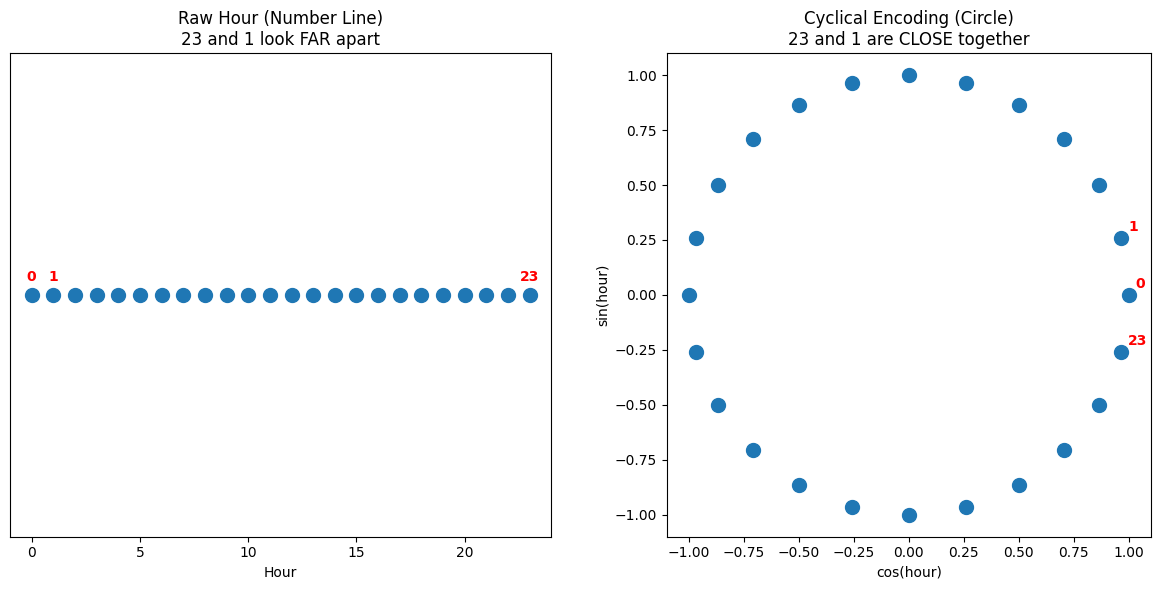

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: raw hour on a number line (0-23)
hours = np.arange(24)
axes[0].scatter(hours, np.zeros(24), s=100)
for h in [23, 0, 1]:
    axes[0].annotate(str(h), (h, 0), textcoords="offset points", xytext=(0,10), ha='center', color='red', fontweight='bold')
axes[0].set_title('Raw Hour (Number Line)\n23 and 1 look FAR apart')
axes[0].set_xlabel('Hour')
axes[0].set_yticks([])
axes[0].set_xlim(-1, 24)

# Right: sin/cos on a circle
sin_vals = np.sin(2 * np.pi * hours / 24)
cos_vals = np.cos(2 * np.pi * hours / 24)
axes[1].scatter(cos_vals, sin_vals, s=100)
for h in [23, 0, 1]:
    axes[1].annotate(str(h), (cos_vals[h], sin_vals[h]), textcoords="offset points", xytext=(5,5), color='red', fontweight='bold')
axes[1].set_title('Cyclical Encoding (Circle)\n23 and 1 are CLOSE together')
axes[1].set_xlabel('cos(hour)')
axes[1].set_ylabel('sin(hour)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
def raw_distance(h1, h2):
    return abs(h1 - h2)

def cyclical_distance(h1, h2):
    s1, c1 = np.sin(2*np.pi*h1/24), np.cos(2*np.pi*h1/24)
    s2, c2 = np.sin(2*np.pi*h2/24), np.cos(2*np.pi*h2/24)
    return np.sqrt((s1-s2)**2 + (c1-c2)**2)

print(f"Raw distance between 23 pm and 1 am: {raw_distance(23, 1)}")
print(f"Cyclical distance between 23 pm and 1 am: {cyclical_distance(23, 1):.3f}")
print()
print(f"Raw distance between 23 pm and 12 pm: {raw_distance(23, 12)}")
print(f"Cyclical distance between 23 pm and 12 pm: {cyclical_distance(23, 12):.3f}")

Raw distance between 23 pm and 1 am: 22
Cyclical distance between 23 pm and 1 am: 0.518

Raw distance between 23 pm and 12 pm: 11
Cyclical distance between 23 pm and 12 pm: 1.983


## Feature Engineering

### Cyclical Encoding for Bedtime/Wakeup Hour

**Why not just use the raw hour number?** Hour-of-day loops around,
23 (11pm) and 1 (1am) are actually only 2 hours apart, but if you encoded them as plain numbers, a model would see them as 22 units
apart, which is basically backwards. Since a lot of people in this
dataset go to bed close to midnight, this would've messed with the
model's ability to recognize "went to bed around midnight" as a
consistent pattern.

**Fix:** encode each hour as (sin, cos) coordinates on a 24-hour
circle instead of a straight number line. This keeps hours that are
close in real time close in the encoded feature space too, midnight
wraparound included.

Checked this two ways, visually (circle plot showing 23 and 1 sitting
right next to each other) and numerically:

- Raw distance between hour 23 and hour 1: 22
- Cyclical distance between hour 23 and hour 1: ~0.52

That confirms the fix actually does what it's supposed to.

In [ ]:
# Does sleep efficiency differ between rows WITH missing alcohol data vs WITHOUT?
missing_alcohol = df[df['Alcohol consumption'].isna()]
has_alcohol = df[df['Alcohol consumption'].notna()]

print(f"Rows missing alcohol data: {len(missing_alcohol)}")
print(f"Mean efficiency (missing alcohol): {missing_alcohol['Sleep efficiency'].mean():.3f}")
print(f"Mean efficiency (has alcohol): {has_alcohol['Sleep efficiency'].mean():.3f}")

from scipy import stats
t_stat, p_val = stats.ttest_ind(missing_alcohol['Sleep efficiency'].dropna(),
                                   has_alcohol['Sleep efficiency'].dropna())
print(f"p-value: {p_val:.4f}")

Rows missing alcohol data: 21
Mean efficiency (missing alcohol): 0.784
Mean efficiency (has alcohol): 0.790
p-value: 0.8349


In [ ]:
rows_before = len(df)
rows_after_dropna = len(df.dropna(subset=['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']))
print(f"Rows before: {rows_before}")
print(f"Rows after dropping any missing: {rows_after_dropna}")
print(f"Rows lost: {rows_before - rows_after_dropna} ({100*(rows_before-rows_after_dropna)/rows_before:.1f}%)")

Rows before: 618
Rows after dropping any missing: 528
Rows lost: 90 (14.6%)


### Missing Data: Is It Random?

Before deciding how to handle the missing values, I wanted to check
whether missingness in Alcohol consumption (our strongest predictor)
was actually random, or whether it might be hiding some bias. Something like what if people with worse sleep were just less likely to log their
drinking?

Compared mean sleep efficiency between rows with missing alcohol data
vs. rows that had it:

- Missing alcohol (n=21): mean efficiency = 0.784
- Has alcohol data (n=597): mean efficiency = 0.790
- Difference: 0.006

Ran a two-sample t-test (H₀: same mean efficiency in both groups) and
got p = 0.835. That means: if missingness really had nothing to do
with efficiency, we'd expect to see a gap this size or bigger about
83.5% of the time just by chance. so this tiny 0.006 difference is
totally unremarkable. For comparison, the real alcohol-efficiency
relationship found earlier had a much bigger gap (~0.15) and a much
smaller p-value (<0.0001), that's what an actual signal looks like,
and this isn't it.

**Conclusion:** missingness here looks random, not tied to the
outcome. Safe to impute without worrying about introducing bias.

I went with median imputation over just dropping the rows, dropping
everything with any missing value across the four affected columns
would've cost 90 rows (14.6% of an already small dataset), which
felt like too much to give up when the alternative (median fill) is
low-risk given the missingness looks random.

One thing worth flagging: Alcohol's median came out to 0.0 (since
over half the dataset reports zero drinks), so the 21 missing rows
are now assumed to be non-drinkers. Given alcohol is our strongest
predictor, this technically nudges those 21 rows toward higher
predicted efficiency, it is a reasonable trade-off given it's a small
slice of the data (3.4%).

In [ ]:
for col in ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val}")

print(f"\nRemaining missing values:\n{df[['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']].isnull().sum()}")

Awakenings: filled with median = 1.0
Caffeine consumption: filled with median = 25.0
Alcohol consumption: filled with median = 0.0
Exercise frequency: filled with median = 2.0

Remaining missing values:
Awakenings              0
Caffeine consumption    0
Alcohol consumption     0
Exercise frequency      0
dtype: int64


In [ ]:
# Simple binary mapping
df['Gender_encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Smoking_encoded'] = df['Smoking status'].map({'No': 0, 'Yes': 1})

# Verify no unexpected values slipped through (e.g., typos, unexpected categories)
print(df['Gender_encoded'].value_counts(dropna=False))
print(df['Smoking_encoded'].value_counts(dropna=False))

Gender_encoded
0    319
1    299
Name: count, dtype: int64
Smoking_encoded
0    409
1    209
Name: count, dtype: int64


### Categorical Encoding

Gender and Smoking status are both simple binary categories, so
just mapped them straight to 0/1 (Male=0/Female=1, No=0/Yes=1),
no need for one-hot encoding here since there's no ordering issue
to worry about with only two categories. One-hot would matter more
for something with 3+ unordered categories, which we don't have.

In [ ]:
feature_cols = [
    'Age', 'Gender_encoded', 'Bedtime_sin', 'Bedtime_cos',
    'Wakeup_sin', 'Wakeup_cos', 'Sleep duration',
    'Caffeine consumption', 'Alcohol consumption',
    'Smoking_encoded', 'Exercise frequency'
]

X = df[feature_cols]
y = df['Sleep efficiency']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures being used:\n{feature_cols}")

Feature matrix shape: (618, 11)
Target shape: (618,)

Features being used:
['Age', 'Gender_encoded', 'Bedtime_sin', 'Bedtime_cos', 'Wakeup_sin', 'Wakeup_cos', 'Sleep duration', 'Caffeine consumption', 'Alcohol consumption', 'Smoking_encoded', 'Exercise frequency']


In [ ]:
print(X.isnull().sum())

Age                     0
Gender_encoded          0
Bedtime_sin             0
Bedtime_cos             0
Wakeup_sin              0
Wakeup_cos              0
Sleep duration          0
Caffeine consumption    0
Alcohol consumption     0
Smoking_encoded         0
Exercise frequency      0
dtype: int64


In [ ]:
print(X.dtypes)

Age                       int64
Gender_encoded            int64
Bedtime_sin             float64
Bedtime_cos             float64
Wakeup_sin              float64
Wakeup_cos              float64
Sleep duration          float64
Caffeine consumption    float64
Alcohol consumption     float64
Smoking_encoded           int64
Exercise frequency      float64
dtype: object


In [ ]:
assert X.isnull().sum().sum() == 0, "NaN values found in feature matrix!"
assert y.isnull().sum() == 0, "NaN values found in target!"
print("No missing values in X or y — safe to proceed.")

No missing values in X or y — safe to proceed.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (494, 11)
Test set: (124, 11)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"Baseline Linear Regression MAE: {mae:.4f}")

Baseline Linear Regression MAE: 0.0954


In [ ]:
naive_pred = [y_train.mean()] * len(y_test)
naive_mae = mean_absolute_error(y_test, naive_pred)
print(f"Naive baseline MAE (always predict mean): {naive_mae:.4f}")
print(f"Linear Regression MAE: {mae:.4f}")

Naive baseline MAE (always predict mean): 0.1142
Linear Regression MAE: 0.0954


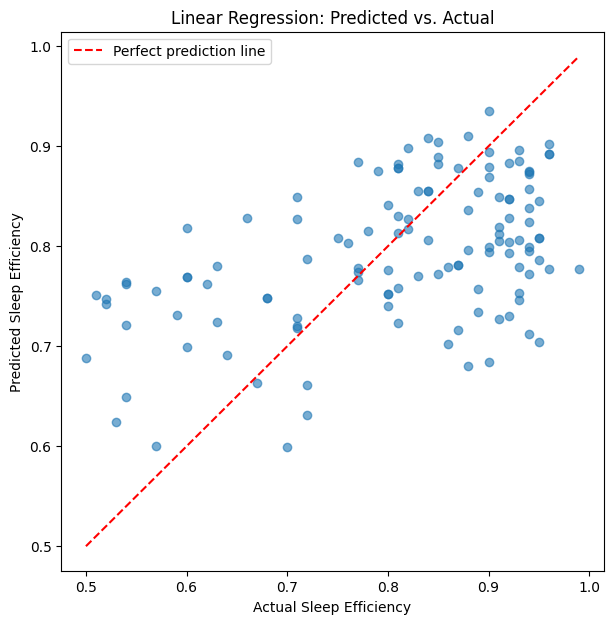

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Perfect prediction line')
plt.xlabel('Actual Sleep Efficiency')
plt.ylabel('Predicted Sleep Efficiency')
plt.title('Linear Regression: Predicted vs. Actual')
plt.legend()
plt.show()

## Baseline Model: Linear Regression

**Setup:** 80/20 train/test split (494 train, 124 test), random_state=42

**Result:** MAE = 0.0954

**Compared against a naive baseline** plainly predicting the training
mean (≈0.79) for everyone, no matter who they are: naive MAE = 0.1142

That's a 16.5% improvement over the naive guess, which at least
confirms the features are picking up real signal, not just noise.

### Predicted vs. Actual

Plotting predictions against the actual values showed something the
single MAE number was hiding: a pretty clear pattern of **regression
to the mean**.

- For low actual efficiency (~0.50-0.65), the model consistently
  *overpredicts* — it's too optimistic about people who are actually
  sleeping poorly
- For high actual efficiency (~0.85-1.0), it consistently
  underpredicts which is too pessimistic about people sleeping well
- Predictions are most accurate in the middle range (~0.75-0.85)

Basically the model is playing it safe, pulling extreme predictions
back toward the average instead of confidently predicting extremes.
This lines up with the low-efficiency cluster we found earlier (n=58,
efficiency ≤ 0.55) where the model performs worst exactly on the group
that matters most for this project's actual use case (someone trying
to track and improve poor sleep). Not a great look for practical
usefulness, even if the average error looks okay on paper.

### Interpretation

The model clearly beats naive guessing, so the features aren't
useless. But whether a ~9.5 percentage point average error is "good
enough" really depends on what you're trying to detect. Our EDA found
about a 15-point gap between low and high alcohol groups. If that's
roughly the size of real behavior-driven effects, then an error of
9.5 points might still be too coarse to reliably tell whether a
specific change actually helped, versus just being noise.

My best guess for why this is happening: linear regression can only
capture straight-line relationships, and alcohol's relationship with
efficiency wasn't perfectly linear across drink levels (there's a
small uptick at 3 drinks that a straight line just can't represent).
That's the whole reason to try tree-based models next, it doesn't
need the relationship to be a straight line to pick up on it.

### A Note on Loss vs. Evaluation Metric

Worth being precise here: MAE was used throughout this project as the
evaluation metric, what we use to judge and report model performance.
It was not, however, the actual loss function each model minimized
during training. Linear Regression internally solves for minimum
squared error (OLS), and both Random Forest and Gradient Boosting
use squared-error-based splitting criteria by default in scikit-learn.
This is a subtle but real distinction, since squared error and MAE
respond differently to large individual errors (squared error
penalizes them much more heavily), there's a possibility our models
were implicitly prioritizing "don't be catastrophically wrong on any
single prediction" during training, while we were separately judging
success by "on average, how far off are predictions." We didn't
explicitly reconcile this in model selection, an interesting
direction for further work would be training directly against MAE
(e.g., using a model that supports MAE as its native loss) to see if
results differ meaningfully.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_pred)

print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Gradient Boosting MAE: {gb_mae:.4f}")
print(f"Linear Regression MAE (baseline): {mae:.4f}")
print(f"Naive MAE (reference floor): {naive_mae:.4f}")

Random Forest MAE: 0.0575
Gradient Boosting MAE: 0.0672
Linear Regression MAE (baseline): 0.0954
Naive MAE (reference floor): 0.1142


In [ ]:
rf_train_pred = rf_model.predict(X_train)
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)

gb_train_pred = gb_model.predict(X_train)
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)

print(f"Random Forest — Train MAE: {rf_train_mae:.4f} | Test MAE: {rf_mae:.4f} | Gap: {rf_mae - rf_train_mae:.4f}")
print(f"Gradient Boosting — Train MAE: {gb_train_mae:.4f} | Test MAE: {gb_mae:.4f} | Gap: {gb_mae - gb_train_mae:.4f}")

Random Forest — Train MAE: 0.0225 | Test MAE: 0.0575 | Gap: 0.0351
Gradient Boosting — Train MAE: 0.0548 | Test MAE: 0.0672 | Gap: 0.0124


In [ ]:
depths_to_try = [3, 5, 7, 10, 15, None]  # None = unlimited

results = []
for depth in depths_to_try:
    model = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_mae = mean_absolute_error(y_train, model.predict(X_train))
    test_mae = mean_absolute_error(y_test, model.predict(X_test))

    results.append({'max_depth': depth, 'train_mae': train_mae, 'test_mae': test_mae, 'gap': test_mae - train_mae})
    print(f"max_depth={depth}: Train MAE={train_mae:.4f} | Test MAE={test_mae:.4f} | Gap={test_mae-train_mae:.4f}")

max_depth=3: Train MAE=0.0755 | Test MAE=0.0787 | Gap=0.0032
max_depth=5: Train MAE=0.0637 | Test MAE=0.0743 | Gap=0.0106
max_depth=7: Train MAE=0.0512 | Test MAE=0.0690 | Gap=0.0178
max_depth=10: Train MAE=0.0342 | Test MAE=0.0624 | Gap=0.0282
max_depth=15: Train MAE=0.0233 | Test MAE=0.0570 | Gap=0.0337
max_depth=None: Train MAE=0.0225 | Test MAE=0.0575 | Gap=0.0351


In [ ]:
from sklearn.model_selection import cross_val_score

for depth in [3, 5, 7, 10, 15, None]:
    model = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    mean_mae = -scores.mean()
    std_mae = scores.std()
    print(f"max_depth={depth}: CV MAE = {mean_mae:.4f} (+/- {std_mae:.4f})")

max_depth=3: CV MAE = 0.0781 (+/- 0.0062)
max_depth=5: CV MAE = 0.0727 (+/- 0.0082)
max_depth=7: CV MAE = 0.0671 (+/- 0.0107)
max_depth=10: CV MAE = 0.0595 (+/- 0.0153)
max_depth=15: CV MAE = 0.0538 (+/- 0.0187)
max_depth=None: CV MAE = 0.0534 (+/- 0.0188)


In [ ]:
from sklearn.model_selection import cross_val_score

for depth in [2, 3, 4, 5, 7]:
    model = GradientBoostingRegressor(n_estimators=100, max_depth=depth, random_state=42)
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    mean_mae = -scores.mean()
    std_mae = scores.std()
    print(f"max_depth={depth}: CV MAE = {mean_mae:.4f} (+/- {std_mae:.4f})")

max_depth=2: CV MAE = 0.0780 (+/- 0.0083)
max_depth=3: CV MAE = 0.0705 (+/- 0.0123)
max_depth=4: CV MAE = 0.0640 (+/- 0.0179)
max_depth=5: CV MAE = 0.0571 (+/- 0.0240)
max_depth=7: CV MAE = 0.0474 (+/- 0.0299)


## Tree-Based Models: Random Forest & Gradient Boosting

After the linear regression baseline (MAE 0.0954), I wanted to try
tree-based models since they can pick up non-linear relationships
that a straight-line model can't, and the EDA already hinted at
this being relevant (alcohol's effect on efficiency wasn't perfectly
linear across drink levels).

**First pass, default settings:**

| Model | Test MAE |
|---|---|
| Linear Regression (baseline) | 0.0954 |
| Random Forest | 0.0575 |
| Gradient Boosting | 0.0672 |

Both tree models beat the baseline by a solid margin, and Random
Forest edged out Gradient Boosting. My first instinct was that
Gradient Boosting would be more prone to overfitting, since it
builds trees sequentially and keeps correcting previous errors,
that can chase noise on a small dataset like this. So I checked the
train/test gap for both to see if that held up.

| Model | Train MAE | Test MAE | Gap |
|---|---|---|---|
| Random Forest | 0.0225 | 0.0575 | 0.0351 |
| Gradient Boosting | 0.0548 | 0.0672 | 0.0124 |

This actually went against my expectation. Random Forest had the
larger gap, not Gradient Boosting. Its training error was almost
suspiciously low (0.0225), which is a sign it's fitting quirks
specific to the training rows rather than just the real underlying
pattern. So even though RF had the better test score, I wasn't fully
confident it was for the right reasons.

**Sweeping across depths, properly this time:**

Instead of guessing at one depth value, I tested a full range:

| max_depth | Train MAE | Test MAE | Gap |
|---|---|---|---|
| 3 | 0.0755 | 0.0787 | 0.0032 |
| 5 | 0.0637 | 0.0743 | 0.0106 |
| 7 | 0.0512 | 0.0690 | 0.0178 |
| 10 | 0.0342 | 0.0624 | 0.0282 |
| 15 | 0.0233 | 0.0570 | 0.0337 |
| None | 0.0225 | 0.0575 | 0.0351 |

Test MAE just kept improving as depth increased, all the way to 15,
then basically flattened out at "unlimited." There's no clear point
where it turns around and gets worse, which surprised me, since I
expected to see a U-shape (test error improving, then reversing as
overfitting kicks in).

**But, this was still only one train/test split.** With a dataset
this small (494 training rows), I got worried the "best" depth might
just be a fluke of which 124 people happened to land in the test set
that particular time, rather than a real, stable pattern. So I ran
5-fold cross-validation instead, which tests each depth across 5
different splits and averages the results:

| max_depth | CV Mean MAE | CV Std Dev |
|---|---|---|
| 3 | 0.0781 | ±0.0062 |
| 5 | 0.0727 | ±0.0082 |
| 7 | 0.0671 | ±0.0107 |
| 10 | 0.0595 | ±0.0153 |
| 15 | 0.0538 | ±0.0187 |
| None | 0.0534 | ±0.0188 |

This confirmed the average-performance trend (deeper = better MAE),
but it also revealed something the single split hid: **the standard
deviation roughly triples** going from depth=3 (±0.006) to depth=None
(±0.019). So while deeper trees do better on average, their
performance also swings around a lot more depending on which rows
end up in training vs. test.

**What I take from this:** this is a genuine bias-variance trade-off,
not a case where one setting is just objectively correct. Shallow
trees (depth=3) are consistent but leave real accuracy on the table
(underfitting). Deep/unlimited trees get the best average accuracy
but are noticeably less stable — meaning the exact MAE you'd report
depends more on luck of the split than I'd like for a small dataset
like this.

**Tentative pick: going with max_depth=10.** It's close to the best CV mean
(0.0595 vs. 0.0534 at unlimited depth) but noticeably more stable
(±0.0153 vs. ±0.0188). I'd rather report a slightly higher error I
can trust than chase the lowest possible number on a dataset this
small, where that number might just reflect a lucky split rather
than a genuinely better model.

```python
rf_final = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_final.fit(X_train, y_train)
```

This is the model I'll carry forward for the rest of the analysis,
comparing against Gradient Boosting properly, and later for feature
importance and failure analysis.

In [ ]:
rf_final = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_final.fit(X_train, y_train)

### Choosing Between Random Forest and Gradient Boosting

Ran the same cross-validated depth sweep for Gradient Boosting to
keep the comparison fair (RF had already been tuned this way).

| max_depth | CV Mean MAE | CV Std Dev |
|---|---|---|
| 2 | 0.0780 | ±0.0083 |
| 3 | 0.0705 | ±0.0123 |
| 4 | 0.0640 | ±0.0179 |
| 5 | 0.0571 | ±0.0240 |
| 7 | 0.0474 | ±0.0299 |

Same pattern as Random Forest, mean MAE keeps improving with depth,
but here the instability grows even faster. At depth=7, GB's std
(±0.0299) is almost double RF's worst case (±0.0188 at unlimited
depth). That's a real problem for a dataset this small (494
training rows). A model whose reported error could swing by ±0.03
depending on the random split isn't something I'd want to build the
rest of the evaluation on, even if its best single run looks
impressive.

**Final decision: Random Forest, max_depth=10.** It doesn't have the
single lowest CV mean anywhere in either table, but it offers the
best balance of accuracy (0.0595) and reliability (±0.0153).
Gradient Boosting's numbers looked more attractive on paper, but the
instability made me trust them less, especially with this small a
dataset. This feels like the more honest choice for a model I'm
actually claiming to have evaluated properly, not just the one that
happened to post the best number in one run.

In [ ]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

                 feature  importance
0                    Age    0.230415
8    Alcohol consumption    0.222858
9        Smoking_encoded    0.156201
10    Exercise frequency    0.132765
6         Sleep duration    0.055707
7   Caffeine consumption    0.050482
5             Wakeup_cos    0.039001
3            Bedtime_cos    0.033676
2            Bedtime_sin    0.031348
4             Wakeup_sin    0.029305
1         Gender_encoded    0.018243


In [ ]:
smokers = df[df['Smoking status'] == 'Yes']
non_smokers = df[df['Smoking status'] == 'No']

print(f"Smokers (n={len(smokers)}): mean efficiency = {smokers['Sleep efficiency'].mean():.3f}")
print(f"Non-smokers (n={len(non_smokers)}): mean efficiency = {non_smokers['Sleep efficiency'].mean():.3f}")

from scipy import stats
t_stat, p_val = stats.ttest_ind(smokers['Sleep efficiency'], non_smokers['Sleep efficiency'])
print(f"p-value: {p_val:.4f}")
print(f"p-value: {p_val:.24f}")

NameError: name 'df' is not defined

In [ ]:
print(f"Smokers mean age: {smokers['Age'].mean():.1f}")
print(f"Non-smokers mean age: {non_smokers['Age'].mean():.1f}")

Smokers mean age: 41.1
Non-smokers mean age: 40.0


In [ ]:
t_stat, p_val = stats.ttest_ind(smokers['Age'], non_smokers['Age'])
print(f"Age comparison p-value: {p_val:.4f}")

Age comparison p-value: 0.3237


### Feature Importance: An Unexpected Finding, Smoking Status

Random Forest's feature importance ranked Smoking status as the
3rd most important feature (0.156), behind Age (0.230) and Alcohol
(0.223), but ahead of Exercise (0.133). This surprised me a bit,
Smoking never came up in the EDA phase the way Alcohol and Age did,
so I wanted to actually check whether it holds up.

**Checking the relationship directly:**

H₀: Smokers and non-smokers have the same mean sleep efficiency
H₁: Smokers and non-smokers have different mean sleep efficiency

- Smokers (n=209): mean efficiency = 0.739
- Non-smokers (n=409): mean efficiency = 0.816
- Gap: 0.077
- p < 0.0001

Assuming H₀ is true (no real difference), a gap this large or
larger would happen less than 1 in 10,000 times by chance alone.
That's extremely unlikely, so I'm rejecting H₀. This provides
strong evidence that smoking status is genuinely associated with
sleep efficiency in this dataset, not just noise.

**Checking for a confound with Age:** since Age was the #1 feature,
I wanted to rule out the possibility that Smoking's importance was
just "borrowing" from Age (e.g., if smokers happened to skew a lot
older or younger, the model might be using Smoking as a rough stand-in
for Age rather than smoking having its own independent effect).

- Smokers mean age: 41.1
- Non-smokers mean age: 40.0
- p-value: 0.3237

The two groups are close in age, and the difference is not
statistically significant (p = 0.32), ruling out a meaningful age
difference between smokers and non-smokers. This suggests Smoking's
importance in the model is likely a genuine, independent effect, not
just a proxy for Age.

**What this doesn't tell us:** this is a correlational finding from
observational data. We can't say smoking *causes* worse sleep
efficiency, only that the two are associated in this dataset. There
could be other factors (stress, lifestyle patterns, sleep-disrupting
habits that co-occur with smoking) that explain some or all of this
relationship. Still, given how strongly it shows up both in feature
importance and in the direct comparison, it's a genuinely interesting
finding worth flagging, even without being able to explain the full
mechanism behind it.

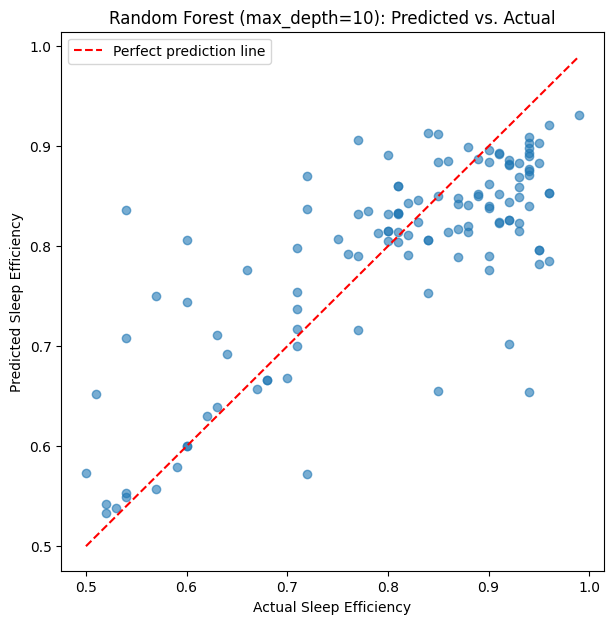

In [ ]:
rf_final_pred = rf_final.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_final_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Perfect prediction line')
plt.xlabel('Actual Sleep Efficiency')
plt.ylabel('Predicted Sleep Efficiency')
plt.title('Random Forest (max_depth=10): Predicted vs. Actual')
plt.legend()
plt.show()

In [ ]:
# Isolate test-set rows where actual efficiency is low
low_eff_mask = y_test <= 0.6
low_eff_actual = y_test[low_eff_mask]
low_eff_pred = rf_final_pred[low_eff_mask]

low_eff_error = (low_eff_pred - low_eff_actual)  # positive = overprediction
print(f"Number of low-efficiency test cases (actual <= 0.6): {len(low_eff_actual)}")
print(f"Mean actual efficiency: {low_eff_actual.mean():.3f}")
print(f"Mean predicted efficiency: {low_eff_pred.mean():.3f}")
print(f"Mean error (predicted - actual): {low_eff_error.mean():.3f}")
print(f"This means the model overpredicts this group by {low_eff_error.mean():.3f} on average" if low_eff_error.mean() > 0 else "underpredicts")

Number of low-efficiency test cases (actual <= 0.6): 16
Mean actual efficiency: 0.554
Mean predicted efficiency: 0.633
Mean error (predicted - actual): 0.078
This means the model overpredicts this group by 0.078 on average


In [ ]:
low_eff_pred_lr = y_pred[low_eff_mask]
low_eff_error_lr = (low_eff_pred_lr - low_eff_actual)
print(f"Linear Regression mean predicted efficiency (low-eff group): {low_eff_pred_lr.mean():.3f}")
print(f"Linear Regression mean error (predicted - actual): {low_eff_error_lr.mean():.3f}")

Linear Regression mean predicted efficiency (low-eff group): 0.724
Linear Regression mean error (predicted - actual): 0.170


### Failure Analysis: Does Random Forest Fix Linear Regression's Weak Spot?

Linear regression showed a clear pattern in its Predicted vs. Actual
plot, it overpredicted for low actual efficiency and underpredicted
for high actual efficiency (regression to the mean). Since Random
Forest improved overall MAE (0.0954 → 0.0624), I wanted to check
whether it actually fixed this specific problem, or just got better
on average while leaving this weak spot intact.

**Visual comparison:**

Random Forest's points cluster much more tightly around the perfect
prediction line overall, especially in the 0.7-0.95 range where most
of the data sits. But looking specifically at the low end (actual
efficiency around 0.5-0.6), points are still sitting above the line,
the overprediction problem is smaller, but it hasn't disappeared.

**Quantifying it properly**, instead of just eyeballing the plot,
I isolated the 16 test-set people with actual efficiency ≤ 0.6
(genuinely poor sleepers) and checked both models on this exact same
group:

| | Linear Regression | Random Forest |
|---|---|---|
| Mean actual efficiency | 0.554 | 0.554 |
| Mean predicted efficiency | 0.724 | 0.633 |
| Mean overprediction | 0.170 | 0.078 |

For context, this group's actual average efficiency is 0.554,
genuinely poor sleep. Linear regression told them, on average, they
were at 0.724, more than double the model's overall error. Random
Forest told them 0.633, still too optimistic, but roughly half as
wrong as linear regression was.

**Why this matters more than the overall MAE number:** if I'd only
looked at the aggregate MAE (LR: 0.0954, RF: 0.0624), I'd have
concluded "RF is better, done." That's true, but it hides something
important, both models share the same underlying weakness, they're
most unreliable exactly for the people my project is meant to help
most. Someone with a real efficiency of 55% is genuinely struggling,
and getting told "you're at 63%" (RF) or worse "you're at 72%" (LR)
is misleading feedback at exactly the moment accurate feedback
matters most. Random Forest is a real

### Single-Person Tests (Before the Full Group Test)

Before testing this systematically, I tried it on one person first,
just to see what would happen.

In [ ]:
import copy

# Grab one real low-efficiency person from the test set
sample_idx = X_test[low_eff_mask].index[0]
sample = X_test.loc[[sample_idx]].copy()

original_pred = rf_final.predict(sample)[0]
print(f"Original alcohol consumption: {sample['Alcohol consumption'].values[0]}")
print(f"Original predicted efficiency: {original_pred:.3f}")

# Simulate reducing alcohol by 1 drink/week
sample_modified = sample.copy()
sample_modified['Alcohol consumption'] = sample_modified['Alcohol consumption'] - 1
sample_modified['Alcohol consumption'] = sample_modified['Alcohol consumption'].clip(lower=0)

modified_pred = rf_final.predict(sample_modified)[0]
print(f"Modified alcohol consumption: {sample_modified['Alcohol consumption'].values[0]}")
print(f"Modified predicted efficiency: {modified_pred:.3f}")
print(f"Predicted change: {modified_pred - original_pred:+.3f}")

Original alcohol consumption: 5.0
Original predicted efficiency: 0.538
Modified alcohol consumption: 4.0
Modified predicted efficiency: 0.523
Predicted change: -0.015


In [ ]:
import copy

# Grab one real low-efficiency person from the test set
sample_idx = X_test[low_eff_mask].index[0]
sample = X_test.loc[[sample_idx]].copy()

original_pred = rf_final.predict(sample)[0]
print(f"Original alcohol consumption: {sample['Alcohol consumption'].values[0]}")
print(f"Original predicted efficiency: {original_pred:.3f}")

# Simulate reducing alcohol by 1 drink/week
sample_modified = sample.copy()
sample_modified['Alcohol consumption'] = sample_modified['Alcohol consumption'] - 4
sample_modified['Alcohol consumption'] = sample_modified['Alcohol consumption'].clip(lower=0)

modified_pred = rf_final.predict(sample_modified)[0]
print(f"Modified alcohol consumption: {sample_modified['Alcohol consumption'].values[0]}")
print(f"Modified predicted efficiency: {modified_pred:.3f}")
print(f"Predicted change: {modified_pred - original_pred:+.3f}")

Original alcohol consumption: 5.0
Original predicted efficiency: 0.538
Modified alcohol consumption: 1.0
Modified predicted efficiency: 0.744
Predicted change: +0.206


In [ ]:
# Test the alcohol-reduction sensitivity across multiple people in the low-eff group
low_eff_indices = X_test[low_eff_mask].index

results = []
for idx in low_eff_indices:
    sample = X_test.loc[[idx]].copy()
    original_pred = rf_final.predict(sample)[0]

    sample_modified = sample.copy()
    sample_modified['Alcohol consumption'] = (sample_modified['Alcohol consumption'] - 1).clip(lower=0)
    modified_pred = rf_final.predict(sample_modified)[0]

    results.append({
        'original_alcohol': sample['Alcohol consumption'].values[0],
        'original_pred': original_pred,
        'modified_pred': modified_pred,
        'change': modified_pred - original_pred
    })

results_df_real = results_df[results_df['original_alcohol'] > 0]
print(results_df_real)
print(f"\nMean predicted change (excluding no-op cases at alcohol=0): {results_df_real['change'].mean():.4f}")
print(f"Number where efficiency increased: {(results_df_real['change'] > 0).sum()} / {len(results_df_real)}")
print(f"Number where efficiency decreased: {(results_df_real['change'] < 0).sum()} / {len(results_df_real)}")

    original_alcohol  original_pred  modified_pred    change
0                5.0       0.537989       0.523331 -0.014658
1                2.0       0.533536       0.855359  0.321823
3                2.0       0.579683       0.772181  0.192497
4                5.0       0.557315       0.553802 -0.003514
5                1.0       0.750224       0.789421  0.039197
7                3.0       0.549680       0.547076 -0.002605
8                3.0       0.573236       0.576247  0.003011
13               4.0       0.805830       0.810030  0.004200

Mean predicted change (excluding no-op cases at alcohol=0): 0.0675
Number where efficiency increased: 5 / 8
Number where efficiency decreased: 3 / 8


### Loss vs. Objective: Does MAE Actually Serve the Use Case?

MAE is a reasonable choice for training, it's interpretable and
treats over and under-prediction symmetrically. But it's worth being
precise about what it does and doesn't guarantee for the actual goal
here, helping someone track whether a lifestyle change is improving
their sleep.

MAE measures average single-point accuracy across different people
in a test set. It says nothing directly about whether the model
responds *sensibly* when one person's inputs change, which is really
what "did this change help me" requires. So instead of just
discussing this abstractly, I tested it directly, simulating a
reduction in alcohol consumption and checking what the model predicts.

**First test, one person:** starting alcohol=5, reducing to alcohol=4
predicted a small *decrease* in efficiency (-0.015), the opposite
direction from what the EDA group averages would suggest. Testing
the same person with a bigger reduction (alcohol 5→1) predicted a
large *increase* (+0.206). Same person, same direction of change,
but the model's response wasn't smooth or consistent, small steps
and large steps didn't agree on direction.

**This turned out to be a real, general pattern, not a one-off.**
Random Forest builds decision boundaries out of thresholds rather
than a smooth curve like linear regression does. If a person's
alcohol value sits near a split point some tree happened to learn,
crossing it can cause a big jump in prediction, while moving within
a region between splits can do very little, or even move slightly
the "wrong" way depending on how that person's other features
interact with the tree structure. This is the flip side of the
regression-to-mean problem linear regression showed, LR gives
smooth, predictable (but sometimes wrong) responses, Random Forest
can capture non-linear effects but at the cost of local
inconsistency like this.

**Testing this properly across the low-efficiency group (n=16):**
I ran the same -1 alcohol test for everyone in this group. My first
pass gave a mean change of only +0.034, but I caught a problem with
this number, 8 of the 16 people already had alcohol=0, so reducing
"by 1" did nothing to their input (clipped at zero), meaning their
predicted change was mechanically 0.000, not a real result. Filtering
those out and looking only at the 8 people who had an actual change
applied:

| Person | Starting alcohol | Predicted change |
|---|---|---|
| 1 | 5.0 | -0.015 |
| 2 | 2.0 | +0.322 |
| 3 | 2.0 | +0.192 |
| 4 | 5.0 | -0.004 |
| 5 | 1.0 | +0.039 |
| 6 | 3.0 | -0.003 |
| 7 | 3.0 | +0.003 |
| 8 | 4.0 | +0.004 |

Mean predicted change: +0.068. Five of eight moved in the expected
direction (efficiency increasing as alcohol decreases), three moved
slightly the opposite way, though those three negative cases were
all small in magnitude (-0.003 to -0.015).

**What this means for the use case:** the model is directionally
useful on average, cutting alcohol tends to predict improved
efficiency, consistent with the EDA finding. But it is not reliably
consistent at the individual level, and small changes are
particularly unreliable, sometimes predicting the wrong direction
entirely. This matters because someone using this tool to check "did
my small change help" is exactly the situation where the model is
least trustworthy, it performs better at reflecting large, decisive
changes than small, incremental ones.

**A methodological note worth keeping:** my first attempt at this
test reported a misleadingly low mean change (0.034) because I didn't
notice that half the sample had a floor-constrained, no-op input
change baked in. This is a useful reminder that testing model
behavior, not just reading a summary statistic, requires checking
that the test itself is actually measuring what you think it's
measuring.

**Conclusion:** MAE alone doesn't fully capture what matters for this
project's actual goal. A model with good average accuracy can still
respond unpredictably to small, realistic behavior changes, which is
exactly the scenario this tool is meant to support. A more complete
version of this project would track predicted *change* directly as
an evaluation target, rather than relying solely on single-point MAE,
though that's beyond the current scope.